In [ ]:
from scipy import io
midi_file='../../assets/trainingdata/chords/session_NNTranscription-1-t1.mid'
dataslices_output='data_slices/output'
dataslices_onsets='data_slices/onsets'
num_augmentations=3 # The extra augmentations correspond to the high, mid and tape dist wav files
batch_size=1
sampleRate,input_signal=io.wavfile.read('../../assets/trainingdata/chords/session_original.wav')
audiolen=len(input_signal)
num_midi_classes=88

use_augmentations=True


import numpy as np
import pypianoroll
import pretty_midi

# User-defined sample rate


# Load MIDI file
midi = pretty_midi.PrettyMIDI(midi_file)

# Calculate time resolution (step length in seconds per sample)
step_length = 1 / sampleRate

# Convert to piano roll with the desired time resolution
# pypianoroll resolution parameter is in ticks per beat,
# but you want time in seconds per sample. Use get_piano_roll from pretty_midi:
total_duration = midi.get_end_time()
n_steps = int(total_duration * sampleRate)
piano_roll = midi.get_piano_roll(fs=sampleRate)  # shape: (128, n_steps)
print(piano_roll.shape)
... Test this code 
# The piano_roll array:
# x-axis: sample index (at samplerate, matches audio directly)
# y-axis: MIDI note (0-127)


(128, 12575000)


In [2]:
import mido
import matplotlib.pyplot as plt
import numpy as np

def load_midi_to_event_samples(midi_file_path,samplerate):
    """
    Loads MIDI data from a file, extracts note-on/off events,
    and plots them on a piano roll-like graph, converting all
    timestamps to samples based on the provided samplerate.
    Corrected time tracking for accurate absolute positions.

    Args:
        midi_file_path (str): The path to the MIDI file.
        samplerate (int): The audio sample rate (e.g., 44100, 48000)
                          to convert seconds to samples.
    """
    if samplerate <= 0:
        print("Error: Samplerate must be a positive integer.")
        return

    try:
        mid = mido.MidiFile(midi_file_path)
    except FileNotFoundError:
        print(f"Error: MIDI file not found at '{midi_file_path}'")
        return
    except Exception as e:
        print(f"Error loading MIDI file: {e}")
        return

    notes = []
    active_notes = {}
    
    # Absolute time in seconds, calculated from mido's stream iterator
    current_time_in_seconds = 0.0

    print(f"Processing MIDI file: {midi_file_path}")
    print(f"Number of tracks: {len(mid.tracks)}")

    # Iterate through the MIDI file as a whole stream, ordered by absolute time
    # This correctly accounts for inter-track timing and tempo changes.
    for msg in mid.play(): # mid.play() yields messages with msg.time in seconds
        
        # msg.time from mid.play() is the delta from the *previous* event in the *merged* stream
        #print(msg)
        current_time_in_seconds += msg.time 

        if msg.type == 'note_on':
            # Store the note and its start time (in seconds)
            if msg.velocity > 0: 
                active_notes[msg.note] = current_time_in_seconds
            else: # Treat note_on with velocity 0 as note_off
                if msg.note in active_notes:
                    start_sec = active_notes.pop(msg.note)
                    duration_sec = current_time_in_seconds - start_sec
                    notes.append((msg.note, start_sec, duration_sec))

        elif msg.type == 'note_off':
            # Calculate duration when note_off occurs
            if msg.note in active_notes:
                start_sec = active_notes.pop(msg.note)
                duration_sec = current_time_in_seconds - start_sec
                notes.append((msg.note, start_sec, duration_sec))
        
        # Important: Filter out non-note messages that still advance time
        # The 'play()' iterator handles this, but if you were doing manual
        # tick processing, you'd only consider events that affect notes.
        # However, for correct *time*, all messages are important.

    # Handle any notes that were "on" when the file ended (missing note_off)
    # Assign them a duration until the end of the last recorded event
    for note, start_sec in list(active_notes.items()): # Use list() to iterate a copy
        duration_sec = current_time_in_seconds - start_sec
        notes.append((note, start_sec, duration_sec))



    
    return notes



Processing MIDI file: ../../assets/trainingdata/chords/session_NNTranscription-1-t1.mid
Number of tracks: 1


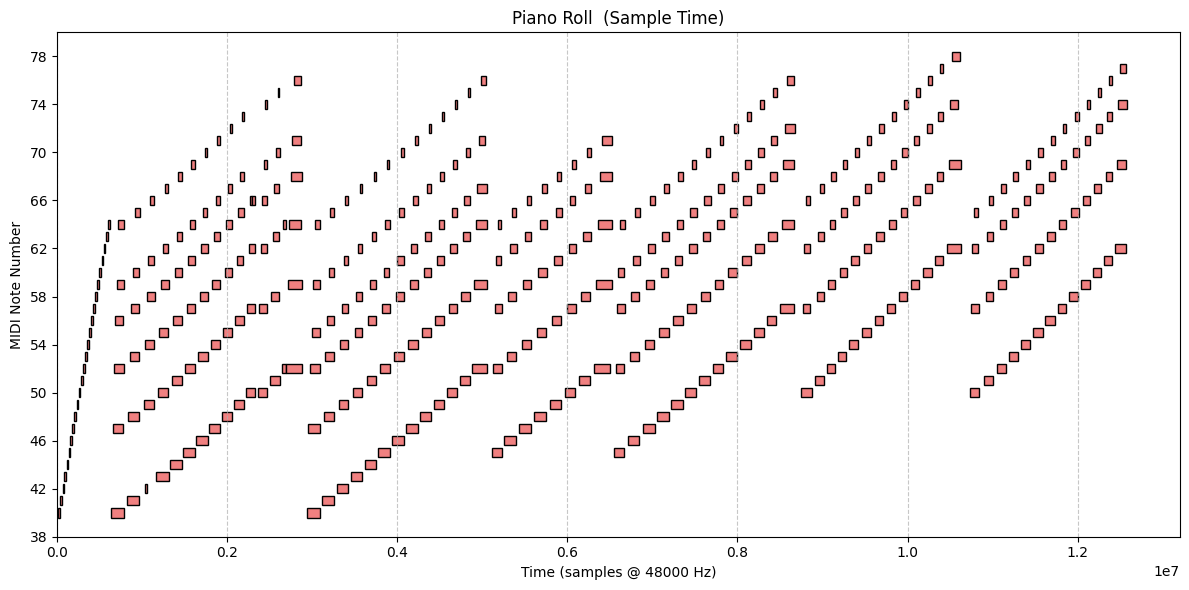

In [3]:
from common import plot_heatmap,save_data_slices,frame_size
def midi_to_note_name(midi_note):
    NOTES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
    octave = (midi_note // 12) - 1 
    note_name = NOTES[midi_note % 12]
    return f"{note_name}{octave}"


def generate_midi_classes(midi_file,samplerate,audiolength):
    
    class_matrix=np.zeros((num_midi_classes+1,audiolength))
    onsetvec=np.zeros(audiolength)
    notes=load_midi_to_event_samples(midi_file,samplerate)
    
    if not notes:
        print("No playable note events found in the MIDI file.")
        return
    num_frames=audiolength//frame_size
    effective_audio_length=frame_size*num_frames
    for n in notes:
        start_sample=int(n[1]*samplerate)
        duration_samples=int(n[2]*samplerate)
        class_matrix[n[0],start_sample:(start_sample+duration_samples)]=1
        
        # onsetvec[range(start_sample-2,start_sample+3)]=onsetvalues
        num_frames=start_sample//frame_size
        effective_start_sample=frame_size*num_frames
        # onsetvec[(effective_start_sample-2*frame_size):(effective_start_sample-frame_size)]=0.25
        # onsetvec[(effective_start_sample-frame_size):(effective_start_sample)]=0.5
        onsetvec[effective_start_sample:(effective_start_sample+frame_size)]=1
        # onsetvec[(effective_start_sample+frame_size):(effective_start_sample+2*frame_size)]=0.5
        # onsetvec[(effective_start_sample+2*frame_size):(effective_start_sample+3*frame_size)]=0.25
        
        
    for s in range(0,audiolength):
        midisamplevec=class_matrix[0:num_midi_classes,s]
        class_matrix[num_midi_classes,s]=np.max(midisamplevec)!=1

    # Convert all times from seconds to samples using the provided samplerate
    note_numbers = [n[0] for n in notes]
    start_times_samples = [int(n[1]*samplerate)  for n in notes] 
    durations_samples = [int(n[2]*samplerate) for n in notes]
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(len(notes)):
        ax.barh(
            y=note_numbers[i],             
            width=durations_samples[i],            
            left=start_times_samples[i],           
            height=0.8,                    
            align='center',
            color='lightcoral', 
            edgecolor='black'
        )

    ax.set_xlabel(f"Time (samples @ {samplerate} Hz)")
    ax.set_ylabel("MIDI Note Number")
    ax.set_title(f"Piano Roll  (Sample Time)")



    # Use the actual min/max of plotted notes for ylim, but ensure it's at least a small range
    if note_numbers:
        min_note = min(note_numbers) - 2
        max_note = max(note_numbers) + 2
    else: # Default for empty notes list
        min_note = 40
        max_note = 80

    ax.set_ylim(min_note, max_note)
    ax.set_xlim(0)
    note_range = max_note - min_note
    if note_range <= 12: 
        y_tick_interval = 1
    elif note_range <= 24: 
        y_tick_interval = 2
    else: 
        y_tick_interval = 4

    y_ticks = np.arange(int(min_note), int(max_note) + 1, y_tick_interval)
    # y_labels = [midi_to_note_name(int(note)) for note in y_ticks]
    ax.set_yticks(y_ticks)
    # ax.set_yticklabels(y_labels)

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()    

    

        
    return class_matrix,onsetvec
 
midi_classes,onsetvec=generate_midi_classes(midi_file,sampleRate,audiolen)  



Downsampling data by a factor of 1000...
(89, 12576000)
Downsampled array shape: (89, 12576)
Creating heatmap...


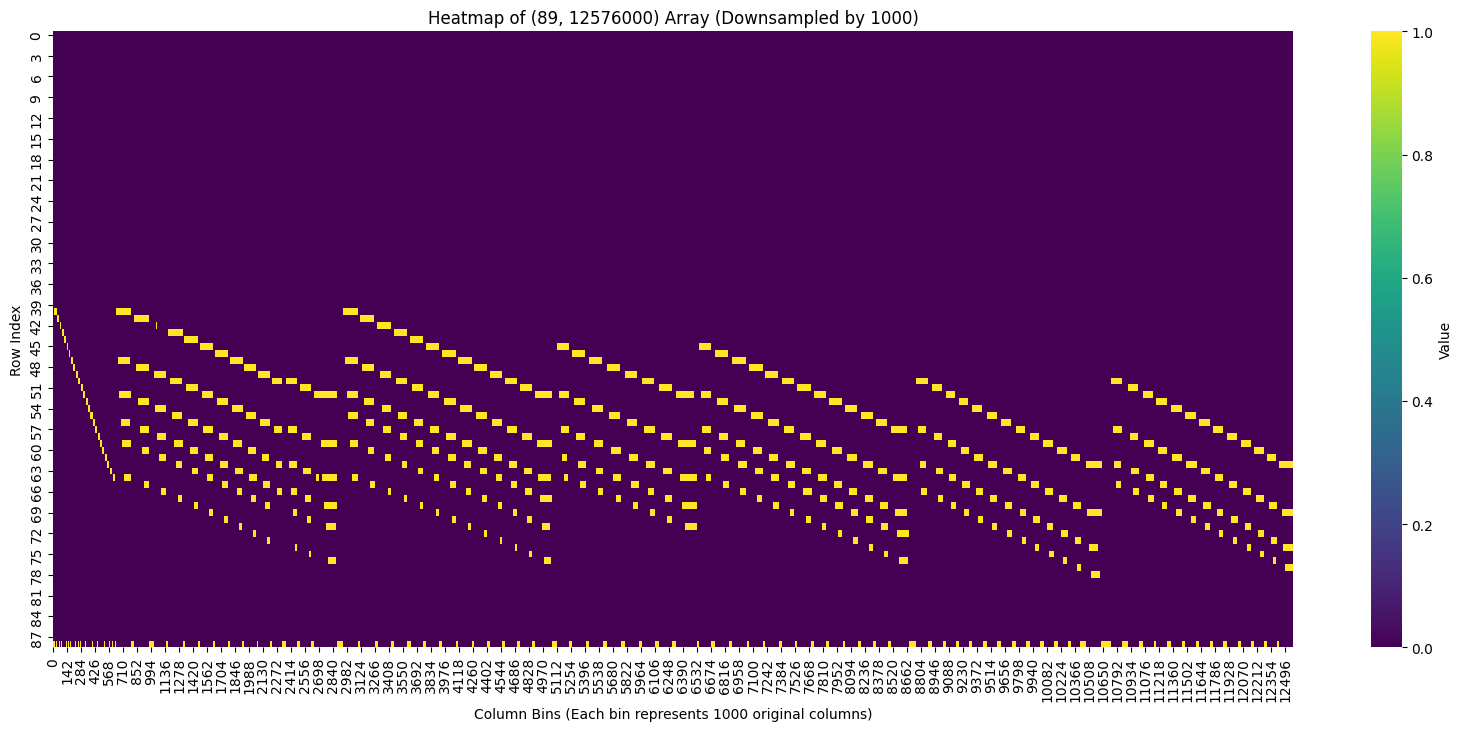

Heatmap displayed.
(89, 12576000)
(1, 12576000)
Downsampling data by a factor of 1000...
(1, 12576000)
Downsampled array shape: (1, 12576)
Creating heatmap...


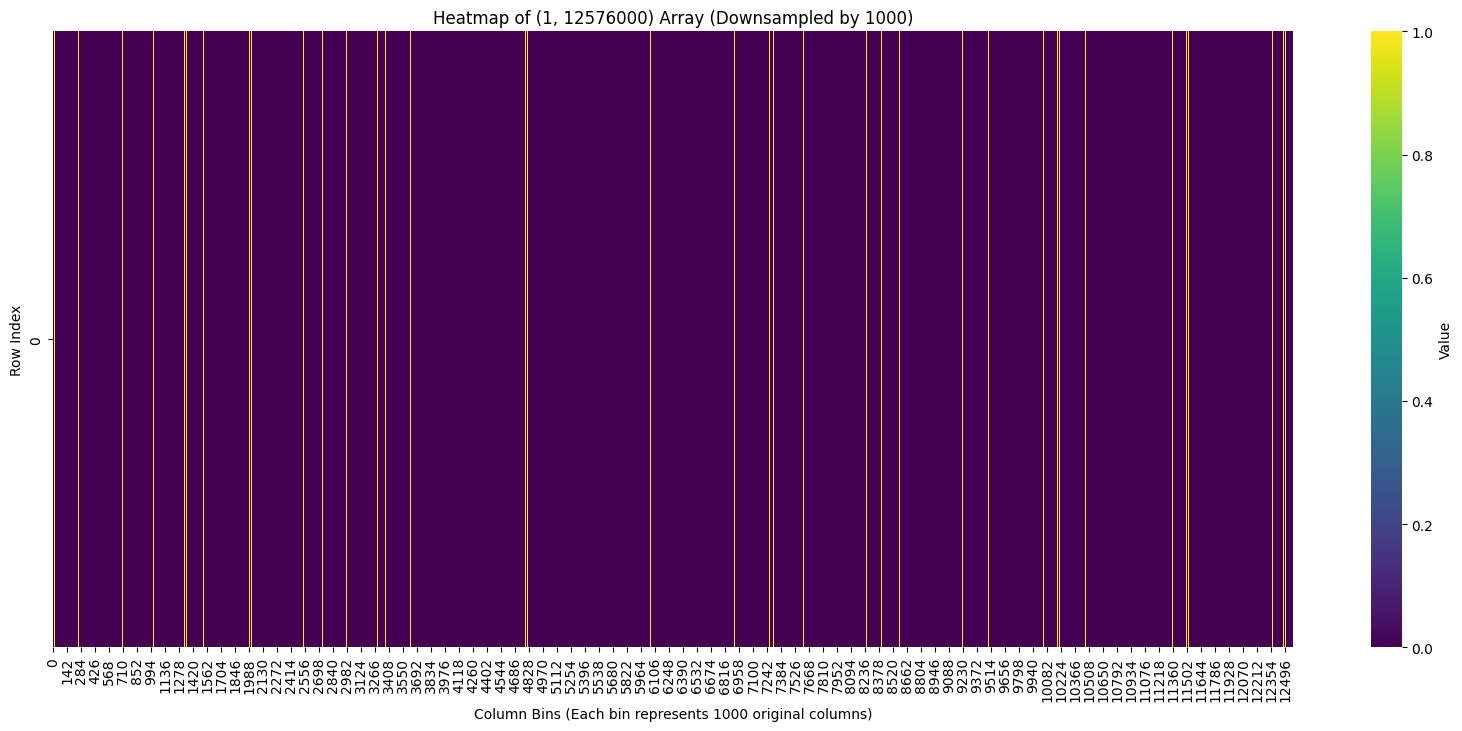

Heatmap displayed.


In [4]:
from common import plot_heatmap
plot_heatmap(midi_classes)
print(midi_classes.shape)
onsets2d=np.tile(onsetvec,(1,1))
print(onsets2d.shape)
plot_heatmap(onsets2d)

In [5]:
from common import frame_size
from common import save_data_slices,reshape_to_nn_output


def savenn_output(directory,nn_classes):   
    nn_output=reshape_to_nn_output(nn_classes)
    if use_augmentations:
        print('Using augmentations')
        nn_output_shape=nn_output.shape
        new_shape=((num_augmentations+1)*nn_output_shape[0],nn_output_shape[1])
        print('Extending nn_output with shape'+str(nn_output.shape),' to new shape '+str(new_shape)+' to include the augmentations')
        nn_output_aug=np.resize(nn_output,new_shape)
        save_data_slices(directory,nn_output_aug,batch_size) 
    else:
        save_data_slices(directory,nn_output,batch_size) 
        
    return nn_output

savenn_output(dataslices_output,midi_classes)
nn_onsets=savenn_output(dataslices_onsets,onsets2d)




reshape data by a factor of 256...
(89, 12576000)
Reshaped the output data to  
(49125, 89)
Using augmentations
Extending nn_output with shape(49125, 89)  to new shape (196500, 89) to include the augmentations
Saving 196500 samples to disk with filenamuber offset 0...
Serialization complete. 196500 Files saved in 'data_slices/output'.
reshape data by a factor of 256...
(1, 12576000)
Reshaped the output data to  
(49125, 1)
Using augmentations
Extending nn_output with shape(49125, 1)  to new shape (196500, 1) to include the augmentations
Saving 196500 samples to disk with filenamuber offset 0...
Serialization complete. 196500 Files saved in 'data_slices/onsets'.


In [6]:
print(nn_onsets[1][0])
num_samples=nn_onsets.shape[0]
num_onset_frames=0
for s in range(0,nn_onsets.shape[0]):
    val=nn_onsets[s][0]
    if val!=0.0:
        print(val)
        num_onset_frames=num_onset_frames+1
        
print('Num onset frames '+str(num_onset_frames)+ ' fraction: '+str(float(num_onset_frames)/num_samples))

0.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


(89, 12576000)
2492158.0


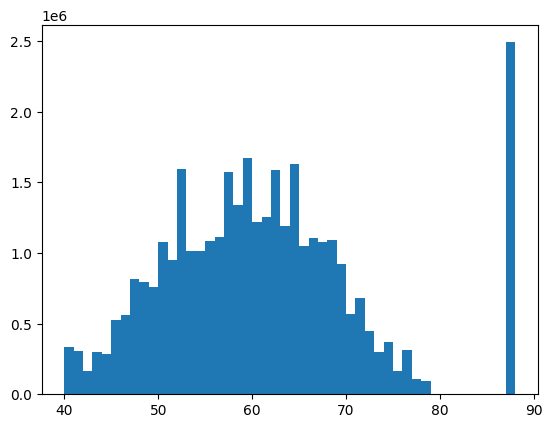

(89,)
1674405.0
max note off weight
0.03823995107854317


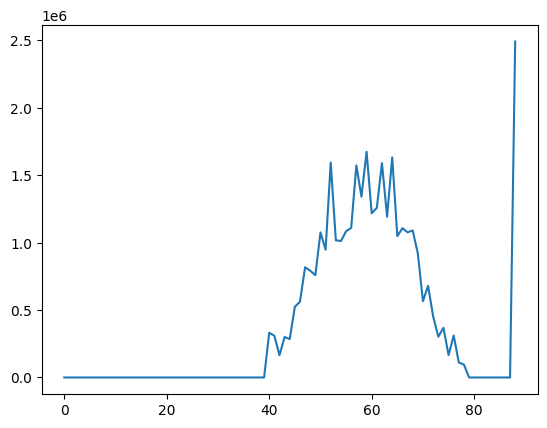

In [7]:
print(midi_classes.shape)
print(np.sum(midi_classes[88]))
midihist=np.zeros(89)
midi_vec=[]
for i in range(0,89):
    midihist[i]=-1
    
    for v in midi_classes[i]:
        if v>0:
            midi_vec.append(i)
    s=np.sum(midi_classes[i])
    if(s>0.0):
        midihist[i]=s
# midi_classes.swapaxes(0,1)
plt.hist(midi_vec,range(40,89))
plt.show()
plt.plot(midihist)
    
print(midihist.shape)
print(np.max(midihist[range(0,88)]))
midimin=1000000000
for i in range(40,89):
    if  midihist[i]>-1:
        if midihist[i]<midimin :
            midimin=midihist[i]
print('max note off weight')       
print(midimin/np.sum(midi_classes[88]))